In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!wget -O /content/drive/MyDrive/food-101.tar.gz \
http://data.vision.ee.ethz.ch/cvl/food-101.tar.gz


--2026-01-20 08:48:06--  http://data.vision.ee.ethz.ch/cvl/food-101.tar.gz
Resolving data.vision.ee.ethz.ch (data.vision.ee.ethz.ch)... 129.132.52.178, 2001:67c:10ec:36c2::178
Connecting to data.vision.ee.ethz.ch (data.vision.ee.ethz.ch)|129.132.52.178|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://data.vision.ee.ethz.ch/cvl/food-101.tar.gz [following]
--2026-01-20 08:48:06--  https://data.vision.ee.ethz.ch/cvl/food-101.tar.gz
Connecting to data.vision.ee.ethz.ch (data.vision.ee.ethz.ch)|129.132.52.178|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4996278331 (4.7G) [application/x-gzip]
Saving to: ‘/content/drive/MyDrive/food-101.tar.gz’

/content/drive/MyDr 100%[===================>]   4.65G  16.1MB/s    in 4m 46s  

2026-01-20 08:52:54 (16.6 MB/s) - ‘/content/drive/MyDrive/food-101.tar.gz’ saved [4996278331/4996278331]



In [ ]:
!tar -xzf /content/drive/MyDrive/food-101.tar.gz -C /content/drive/MyDrive/

In [ ]:
!ls /content/drive/MyDrive/food-101/images | wc -l

101


In [ ]:
import os

DATASET_PATH = "/content/drive/MyDrive/food-101/images"

classes = sorted(os.listdir(DATASET_PATH))
print("Nombre de classes :", len(classes))
print(classes)


Nombre de classes : 101
['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito', 'bruschetta', 'caesar_salad', 'cannoli', 'caprese_salad', 'carrot_cake', 'ceviche', 'cheese_plate', 'cheesecake', 'chicken_curry', 'chicken_quesadilla', 'chicken_wings', 'chocolate_cake', 'chocolate_mousse', 'churros', 'clam_chowder', 'club_sandwich', 'crab_cakes', 'creme_brulee', 'croque_madame', 'cup_cakes', 'deviled_eggs', 'donuts', 'dumplings', 'edamame', 'eggs_benedict', 'escargots', 'falafel', 'filet_mignon', 'fish_and_chips', 'foie_gras', 'french_fries', 'french_onion_soup', 'french_toast', 'fried_calamari', 'fried_rice', 'frozen_yogurt', 'garlic_bread', 'gnocchi', 'greek_salad', 'grilled_cheese_sandwich', 'grilled_salmon', 'guacamole', 'gyoza', 'hamburger', 'hot_and_sour_soup', 'hot_dog', 'huevos_rancheros', 'hummus', 'ice_cream', 'lasagna', 'lobster_bisque', 'lobster_roll_sandwich', 'macaroni_and_cheese

**2) EXPLORATION DES DONNÉES**

2.1 Nombre d’images par classe

In [ ]:
import pandas as pd

data = []
for cls in classes:
    nb = len(os.listdir(os.path.join(DATASET_PATH, cls)))
    data.append([cls, nb])

df = pd.DataFrame(data, columns=["Classe", "Nombre_images"])
df.head()


,Classe,Nombre_images
0,apple_pie,1000
1,baby_back_ribs,1000
2,baklava,1000
3,beef_carpaccio,1000
4,beef_tartare,1000


In [ ]:
import pandas as pd
import os

DATASET_PATH = "/content/drive/MyDrive/food-101/images"

classes = sorted(os.listdir(DATASET_PATH))

data = []
for cls in classes:
    nb = len(os.listdir(os.path.join(DATASET_PATH, cls)))
    data.append([cls, nb])

df = pd.DataFrame(data, columns=["Classe", "Nombre_images"])
df


,Classe,Nombre_images
0,apple_pie,1000
1,baby_back_ribs,1000
2,baklava,1000
3,beef_carpaccio,1000
4,beef_tartare,1000
...,...,...
96,tacos,1000
97,takoyaki,1000
98,tiramisu,1000
99,tuna_tartare,1000


In [ ]:
classes_diff = df[df["Nombre_images"] != 1000]
classes_diff

,Classe,Nombre_images


In [ ]:
df.describe()


,Nombre_images
count,101.0
mean,1000.0
std,0.0
min,1000.0
25%,1000.0
50%,1000.0
75%,1000.0
max,1000.0


Le dataset contient 101 classes

Chaque classe contient exactement 1000 images

Le dataset est donc parfaitement équilibré

2.2 Visualiser des images

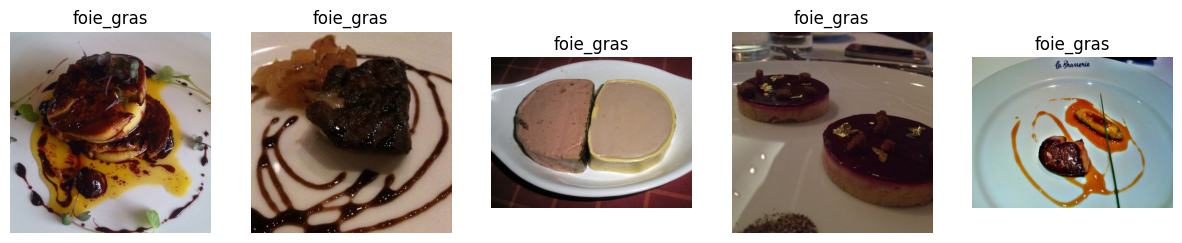

In [ ]:
import matplotlib.pyplot as plt
import cv2
import random

classe = random.choice(classes)
img_dir = os.path.join(DATASET_PATH, classe)
images = random.sample(os.listdir(img_dir), 5)

plt.figure(figsize=(15,5))
for i, img_name in enumerate(images):
    img = cv2.imread(os.path.join(img_dir, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(classe)
    plt.axis("off")
plt.show()


2.3 Taille des images

Food-101 a des tailles variables → preprocessing obligatoire.

In [ ]:
img = cv2.imread(os.path.join(img_dir, images[0]))
print("Taille image :", img.shape)

Taille image : (512, 512, 3)


In [ ]:
img = cv2.imread(os.path.join(img_dir, images[2]))
print("Taille image :", img.shape)


Taille image : (384, 512, 3)


In [ ]:
img = cv2.imread(os.path.join(img_dir, images[1]))
print("Taille image :", img.shape)



Taille image : (512, 511, 3)


L’analyse des dimensions des images du dataset Food-101 montre une hétérogénéité des tailles.
Par exemple, certaines images ont une résolution de 384×512 pixels tandis que d’autres atteignent 512×512 pixels.
Cette variabilité impose une étape de prétraitement afin de redimensionner les images vers une taille fixe avant l’entraînement du modèle.

**preprocessing**

Uniformiser la taille des images

Uniformiser la taille SANS modifier les images originales

Utilisée en Deep Learning (la meilleure pratique)

redimensionne automatiquement chaque image

(redimension + normalisation + split train/val)

### **preprocessing général**

In [ ]:
#from tensorflow.keras.preprocessing.image import ImageDataGenerator
""""IMG_SIZE = (224, 224)
BATCH_SIZE = 32
DATASET_PATH = "/content/drive/MyDrive/food-101/images"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,     # 🔥 Uniformisation ici
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,     # 🔥 Uniformisation ici
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)""""""


Found 80800 images belonging to 101 classes.
Found 20200 images belonging to 101 classes.


In [ ]:
print("Nombre de classes :", train_generator.num_classes)
print("Classes :", train_generator.class_indices)
print("Taille d'un batch :", train_generator[0][0].shape)

Nombre de classes : 101
Classes : {'apple_pie': 0, 'baby_back_ribs': 1, 'baklava': 2, 'beef_carpaccio': 3, 'beef_tartare': 4, 'beet_salad': 5, 'beignets': 6, 'bibimbap': 7, 'bread_pudding': 8, 'breakfast_burrito': 9, 'bruschetta': 10, 'caesar_salad': 11, 'cannoli': 12, 'caprese_salad': 13, 'carrot_cake': 14, 'ceviche': 15, 'cheese_plate': 16, 'cheesecake': 17, 'chicken_curry': 18, 'chicken_quesadilla': 19, 'chicken_wings': 20, 'chocolate_cake': 21, 'chocolate_mousse': 22, 'churros': 23, 'clam_chowder': 24, 'club_sandwich': 25, 'crab_cakes': 26, 'creme_brulee': 27, 'croque_madame': 28, 'cup_cakes': 29, 'deviled_eggs': 30, 'donuts': 31, 'dumplings': 32, 'edamame': 33, 'eggs_benedict': 34, 'escargots': 35, 'falafel': 36, 'filet_mignon': 37, 'fish_and_chips': 38, 'foie_gras': 39, 'french_fries': 40, 'french_onion_soup': 41, 'french_toast': 42, 'fried_calamari': 43, 'fried_rice': 44, 'frozen_yogurt': 45, 'garlic_bread': 46, 'gnocchi': 47, 'greek_salad': 48, 'grilled_cheese_sandwich': 49, 'g

### **le choix du modèle**

EfficientNetB0 ✅ → léger, rapide, précis

Pourquoi pas ViT ou ResNet101 ? → trop lourds, inference lente, nécessite GPU puissant

| Modèle | Après sauvegarde → inférence CPU | Après sauvegarde → inférence GPU |
|--------|-------------------------------|-------------------------------|
| EfficientNetB0 | rapide ✅ | très rapide ✅ |
| ResNet101 | lent ❌ | moyen / rapide ✔️ |
| ViT | très lent ❌ | moyen ✔️ (GPU puissant nécessaire) |


### **🔹 Preprocessing optimisé pour EfficientNetB0**

de la normalisation requise par EfficientNetB0,

de la data augmentation légère pour améliorer la robustesse,

de la stabilité et rapidité pour l’entraînement et l’inférence.

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

# Paramètres
IMG_SIZE = (224, 224)   # Taille recommandée pour EfficientNetB0
BATCH_SIZE = 32
DATASET_PATH = "/content/drive/MyDrive/food-101/images"

# Data augmentation légère + normalisation
datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # 🔥 normalisation spécifique EfficientNet
    rotation_range=15,          # rotation aléatoire
    width_shift_range=0.1,      # translation horizontale
    height_shift_range=0.1,     # translation verticale
    zoom_range=0.1,             # léger zoom
    horizontal_flip=True,       # flip horizontal
    validation_split=0.2        # 20% validation
)

# Générateur pour entraînement
train_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True
)

# Générateur pour validation
val_generator = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)


Found 80800 images belonging to 101 classes.
Found 20200 images belonging to 101 classes.


## **Charger le modèle pré-entraîné EfficientNetB0** et  **Ajouter les couches personnalisées pour 101 classes**

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Charger EfficientNetB0 sans la dernière couche (top)
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Ajouter les couches personnalisées pour 101 classes
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
predictions = Dense(101, activation='softmax')(x)

# Créer le modèle final
model = Model(inputs=base_model.input, outputs=predictions)

# Geler toutes les couches EfficientNet au début
for layer in base_model.layers:
    layer.trainable = False

# Compiler le modèle
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


# **Entraînement initial (avec couches gelées)**

✅ Rapidité : seulement les nouvelles couches sont entraînées

✅ Stabilité : pas de risque de déstabiliser EfficientNetB0

**Avantages :**

Tu vois la base de performance avant de toucher au modèle pré-entraîné

In [ ]:
EPOCHS = 10

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
 929/2525 ━━━━━━━━━━━━━━━━━━━━ 7:41:47 17s/step - accuracy: 0.3834 - loss: 2.5864

In [ ]:
loss, acc = model.evaluate(val_generator)
print("Validation Accuracy après entraînement initial :", acc)


## **Fine**-**tuning**

In [ ]:
# Débloquer les dernières couches du modèle EfficientNet
for layer in base_model.layers[-20:]:  # par exemple les 20 dernières
    layer.trainable = True

# Recompiler le modèle (important après avoir changé trainable)
model.compile(
    optimizer=Adam(learning_rate=1e-5),  # learning rate plus petit
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Continuer l’entraînement
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

In [ ]:
loss, acc = model.evaluate(val_generator)
print("Validation Accuracy après fine-tuning :", acc)


# **Sauvegarde du modèle pour production**

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/models/food-101-efficientnetb0"
model.save(MODEL_PATH)


# **Chargement du modèle sauvegardé**

In [ ]:
from tensorflow.keras.models import load_model

model = load_model(MODEL_PATH)


## **Préparation des images pour prédiction**

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

IMG_PATH = "/path/to/new_image.jpg"
img = image.load_img(IMG_PATH, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array)  # 🔥 normalisation EfficientNet

pred = model.predict(img_array)
class_index = np.argmax(pred)
print("Classe prédite :", class_index)
